# PCA-19 пространство белков — 3D-проекция, раскраска по семьям

`k_prot = 19` — та самая размерность, на которой был зафиксирован белок в
`molecule_embeddings/pca_rotation_screening.ipynb` (точка из log-сетки
`[4, 7, 11, 19, 31, 52, 86, 144, 240, 392]` протеинового ноутбука), пока мы
варьировали молекулярную сторону. Здесь смотрим глазами, что вообще
представляет собой это 19-мерное пространство: строим 3D-проекцию (t-SNE и
UMAP) и красим точки по семье рецептора (17 семей OR, как в `esm_screening.ipynb`).

PCA-19 обучается на **всех** 409 curated-рецепторах (это чисто описательная
визуализация, не тренировка модели — утечка здесь не имеет смысла).

In [1]:
import sys, warnings, re
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from orbind import dataset as D

DATA = ROOT / 'data'
FIG  = ROOT / 'notebooks' / 'protein_embeddings' / 'figures'; FIG.mkdir(parents=True, exist_ok=True)
print('repo root:', ROOT)

repo root: <repo>


In [ ]:
# --- данные ---------------------------------------------------------------
_esm_full = D.load_npz_dict(DATA / 'embeddings' / 'proteins' / 'esm2_650m_mean_full.npz')
_curated_recs = set(pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')['receptor'])
ESM = {k: v for k, v in _esm_full.items() if k in _curated_recs}
keys = list(ESM.keys())
print(f'рецепторов: {len(keys)}  dim={next(iter(ESM.values())).shape[0]}')

K_PROT = 19   # фиксированная точка из molecule_embeddings/pca_rotation_screening.ipynb

## PCA-19 (описательная, на всём датасете)

Та же схема SVD, что и в остальных PCA-ноутбуках, но без train/test-разбиения
— здесь нет модели, только визуализация геометрии.

In [3]:
def pca_transform_full(emb: dict, k: int) -> dict:
    """PCA fit+project на всех ключах — чисто описательная проекция."""
    keys_all = list(emb.keys())
    X = np.stack([emb[key] for key in keys_all]).astype(np.float64)
    mu = X.mean(0, keepdims=True)
    U, S, Vt = np.linalg.svd(X - mu, full_matrices=False)
    kk = min(k, Vt.shape[0])
    proj = (X - mu) @ Vt[:kk].T
    return {key: v.astype(np.float32) for key, v in zip(keys_all, proj)}, (S[:kk] ** 2) / (len(X) - 1)

ESM_PCA19, eigvals19 = pca_transform_full(ESM, K_PROT)
var_kept = eigvals19.sum() / (np.linalg.svd(
    np.stack([ESM[k] for k in keys]).astype(np.float64) -
    np.stack([ESM[k] for k in keys]).astype(np.float64).mean(0, keepdims=True),
    full_matrices=False, compute_uv=False) ** 2 / (len(keys) - 1)).sum()
print(f'PCA-{K_PROT}: доля сохранённой дисперсии = {var_kept * 100:.2f}%')

X19 = np.stack([ESM_PCA19[k] for k in keys]).astype(np.float64)   # [409, 19]

PCA-19: доля сохранённой дисперсии = 93.17%


## Семьи рецепторов (как в esm_screening.ipynb)

Семья извлекается из выбранного GPCRDB-референса (`bw_ref_used_curated.csv`)
через тот же регэксп `^(or?\d+)`.

In [4]:
bw_ref = pd.read_csv(DATA / 'processed' / 'bw_ref_used_curated.csv')
seq2ref = bw_ref.set_index('receptor')['ref_entry'].to_dict()

def _family(seq):
    slug = seq2ref.get(seq, 'unk_human').replace('_human', '')
    m = re.match(r'^(or?\d+)', slug)
    return m.group(1).upper() if m else slug.upper()

families = np.array([_family(k) for k in keys])
fams_u = sorted(set(families))
print(f'семей: {len(fams_u)}')
print(pd.Series(families).value_counts().to_string())

семей: 17
OR2    98
OR5    69
OR4    39
O10    35
O52    32
OR8    31
O51    29
OR7    26
OR1    13
OR6    10
O14     7
OR9     6
O56     5
OR3     4
O11     3
O12     1
O13     1


## 3D-проекции: t-SNE и UMAP

Обе строятся из одного и того же PCA-19 пространства (не из сырого ESM-1280) —
сравниваем, как две разные техники укладывают одну и ту же 19-мерную геометрию
в 3D.

In [5]:
# --- t-SNE 3D ---------------------------------------------------------------
import sklearn
from sklearn.manifold import TSNE

_kw = 'max_iter' if tuple(int(x) for x in sklearn.__version__.split('.')[:2]) >= (1, 4) else 'n_iter'
print('t-SNE 3D по PCA-19 …')
proj_tsne = TSNE(n_components=3, perplexity=30, random_state=42, init='pca',
                 **{_kw: 1000}).fit_transform(X19)
print('done', proj_tsne.shape)

t-SNE 3D по PCA-19 …
done (409, 3)


In [6]:
# --- UMAP 3D ------------------------------------------------------------
import umap

print('UMAP 3D по PCA-19 …')
proj_umap = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1,
                      random_state=42).fit_transform(X19)
print('done', proj_umap.shape)

UMAP 3D по PCA-19 …
done (409, 3)


## Визуализация: раскраска по семьям

Один и тот же порядок точек (`keys`/`families`) для обеих проекций — цвета и
легенда идентичны на обоих графиках.

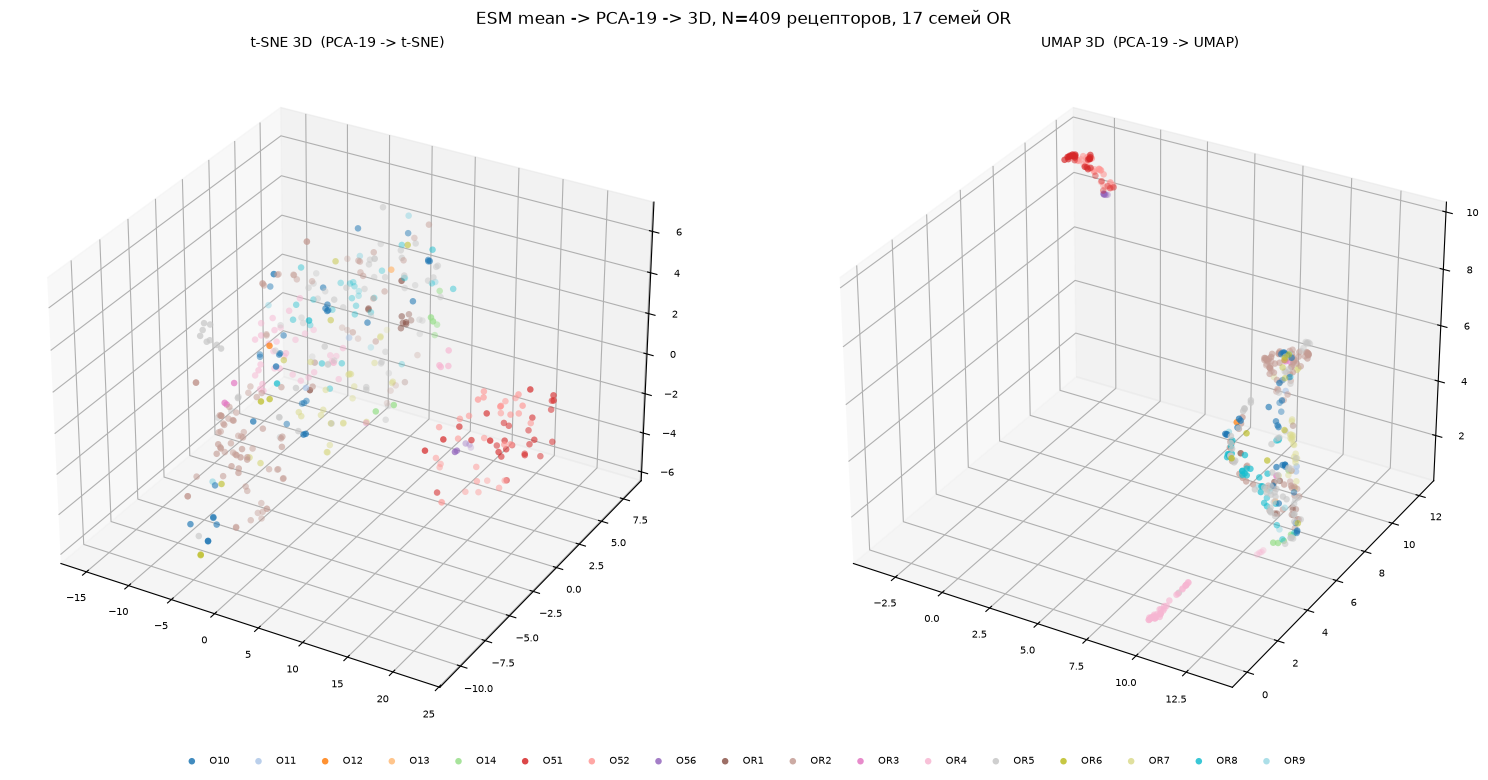

saved -> pca19_family_3d_tsne_umap.png


In [7]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

cmap = plt.get_cmap('tab20', len(fams_u))
fam_color = {f: cmap(i) for i, f in enumerate(fams_u)}

def plot_3d(ax, proj, title):
    for f in fams_u:
        m = families == f
        ax.scatter(proj[m, 0], proj[m, 1], proj[m, 2], s=22, alpha=0.85,
                   color=fam_color[f], label=f, edgecolors='none')
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=7)

fig = plt.figure(figsize=(16, 7.5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

plot_3d(ax1, proj_tsne, f't-SNE 3D  (PCA-{K_PROT} -> t-SNE)')
plot_3d(ax2, proj_umap, f'UMAP 3D  (PCA-{K_PROT} -> UMAP)')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=len(fams_u), fontsize=7,
          bbox_to_anchor=(0.5, -0.04), frameon=False)

fig.suptitle(f'ESM mean -> PCA-{K_PROT} -> 3D, N={len(keys)} рецепторов, '
            f'{len(fams_u)} семей OR', y=0.98)
fig.tight_layout()
fname = FIG / f'pca{K_PROT}_family_3d_tsne_umap.png'
fig.savefig(fname, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved -> {fname.name}')

---
## Раскраска того же белкового пространства по выбранной молекуле

Зеркально к тому, что делали в `molecule_embeddings/molecule_screening.ipynb`
(там красили молекулы по рецептору) — здесь красим **рецепторы** (уже готовые
3D-проекции `proj_tsne`/`proj_umap` из PCA-19) по связи с одной выбранной
молекулой: 🔴 связь + · 🔵 связь − · ⚪ не измерялось.

Номер молекулы стабилен: молекулы упорядочены по убыванию числа рецепторов, с
которыми зафиксирована связь (`n_pos`), тай-брейк — число негативов (`n_neg`).

In [8]:
# --- стабильная нумерация молекул + интересные номера -----------------------
PAIRS = pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')
PAIRS = PAIRS[PAIRS['receptor'].isin(keys)]

gm = PAIRS.groupby('inchikey')['label']
MSTAT = pd.DataFrame({'n_pos': gm.apply(lambda s: int((s == 1).sum())),
                      'n_neg': gm.apply(lambda s: int((s == 0).sum()))})
MSTAT['n_meas']   = MSTAT.n_pos + MSTAT.n_neg
MSTAT['n_unmeas'] = len(keys) - MSTAT.n_meas
MSTAT = MSTAT.sort_values(['n_pos', 'n_neg'], ascending=False, kind='stable').reset_index()
MSTAT.index.name = 'idx'
print(f'молекул: {len(MSTAT)}')

print('\n=== топ по позитивам (широко связывающиеся) ===')
display(MSTAT.head(8)[['n_pos', 'n_neg', 'n_meas', 'n_unmeas']])

_bal = MSTAT.assign(bal=MSTAT[['n_pos', 'n_neg']].min(axis=1)).sort_values('bal', ascending=False)
print('=== сбалансированные (+ и − оба хорошо представлены) ===')
display(_bal.head(8)[['n_pos', 'n_neg', 'n_meas', 'n_unmeas', 'bal']])

print('=== высокое покрытие (больше всего измерено) ===')
display(MSTAT.sort_values('n_meas', ascending=False).head(6)[['n_pos', 'n_neg', 'n_meas', 'n_unmeas']])

print('\nинтересные: #0 (116+/226-, самый широкий + высокое покрытие) · '
      '#2 (87+/280-, высокое покрытие) · #7 (43+/34-, лучший баланс) · '
      '#17 (19+/358-, максимум покрытия)')

молекул: 488

=== топ по позитивам (широко связывающиеся) ===


,n_pos,n_neg,n_meas,n_unmeas
idx,,,,
0,116,226,342,67
1,88,257,345,64
2,87,280,367,42
3,75,276,351,58
4,75,267,342,67
5,61,282,343,66
6,53,287,340,69
7,43,34,77,332


=== сбалансированные (+ и − оба хорошо представлены) ===


,n_pos,n_neg,n_meas,n_unmeas,bal
idx,,,,,
0,116,226,342,67,116
1,88,257,345,64,88
2,87,280,367,42,87
3,75,276,351,58,75
4,75,267,342,67,75
5,61,282,343,66,61
6,53,287,340,69,53
7,43,34,77,332,34


=== высокое покрытие (больше всего измерено) ===


,n_pos,n_neg,n_meas,n_unmeas
idx,,,,
17,19,358,377,32
2,87,280,367,42
13,26,336,362,47
3,75,276,351,58
32,9,342,351,58
16,20,329,349,60



интересные: #0 (116+/226-, самый широкий + высокое покрытие) · #2 (87+/280-, высокое покрытие) · #7 (43+/34-, лучший баланс) · #17 (19+/358-, максимум покрытия)


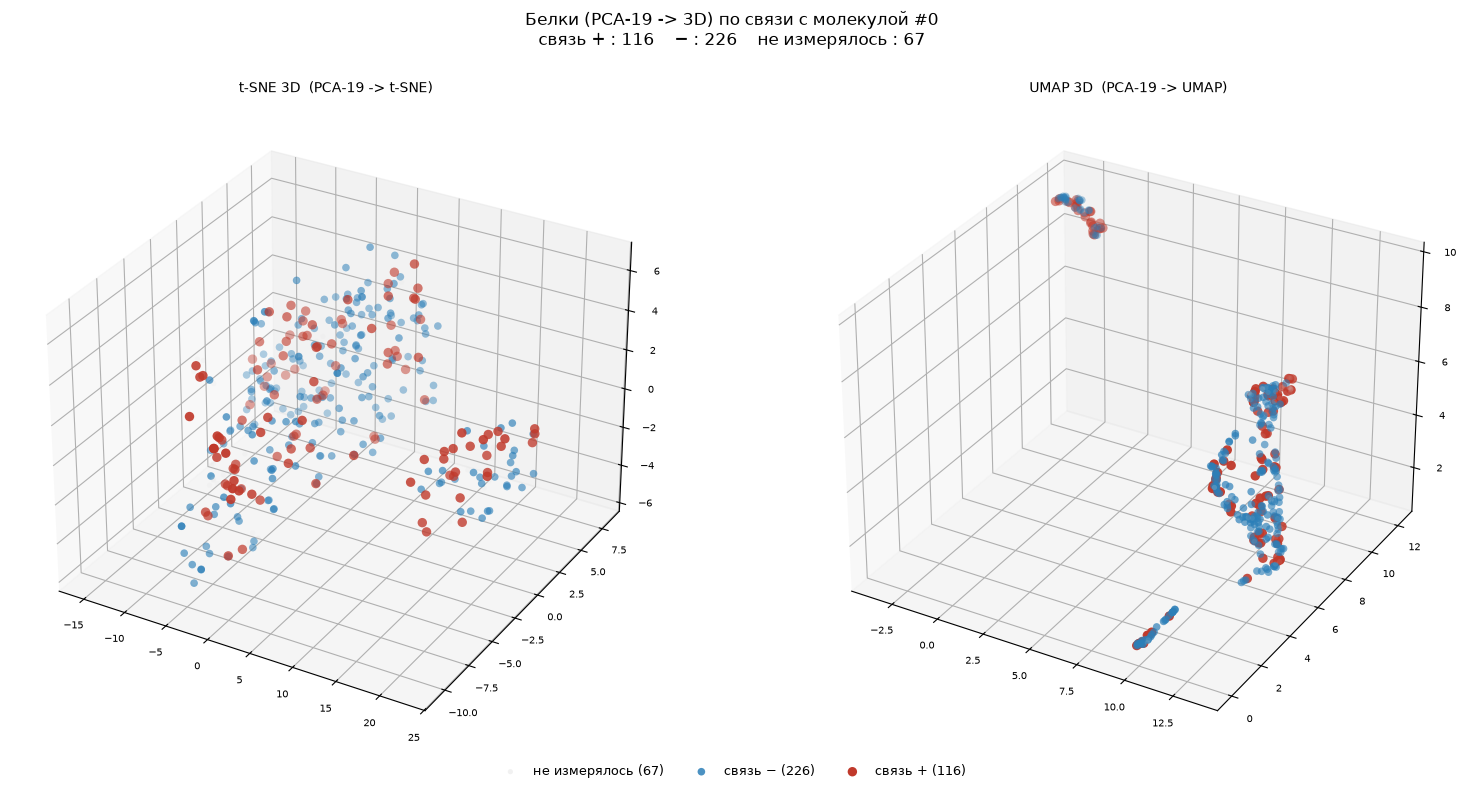

saved -> pca19_molecule0_3d_tsne_umap.png


In [9]:
# --- раскраска белкового пространства по выбранной молекуле -----------------
MOLECULE_IDX = 0          # <<< меняй номер молекулы здесь (см. таблицы выше)

ik = MSTAT.loc[MOLECULE_IDX, 'inchikey']
sub = PAIRS[PAIRS['inchikey'] == ik]
lab = dict(zip(sub['receptor'], sub['label']))
codes = np.array([lab.get(k, -1) for k in keys])        # 1 = +, 0 = −, -1 = не измерялось

GROUPS = [(-1, '#d8d8d8', 14, 0.35, 'не измерялось'),
          ( 0, '#2c7fb8', 30, 0.85, 'связь −'),
          ( 1, '#c0392b', 46, 1.00, 'связь +')]

def plot_3d_by_molecule(ax, proj, title):
    for c, col, s, al, name in GROUPS:
        m = codes == c
        ax.scatter(proj[m, 0], proj[m, 1], proj[m, 2], c=col, s=s, alpha=al,
                   edgecolors='none', label=f'{name} ({int(m.sum())})')
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=7)

fig = plt.figure(figsize=(16, 7.5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

plot_3d_by_molecule(ax1, proj_tsne, f't-SNE 3D  (PCA-{K_PROT} -> t-SNE)')
plot_3d_by_molecule(ax2, proj_umap, f'UMAP 3D  (PCA-{K_PROT} -> UMAP)')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=9,
          bbox_to_anchor=(0.5, -0.03), frameon=False)

n_pos, n_neg, n_unm = int((codes == 1).sum()), int((codes == 0).sum()), int((codes == -1).sum())
fig.suptitle(f'Белки (PCA-{K_PROT} -> 3D) по связи с молекулой #{MOLECULE_IDX}\n'
            f'связь + : {n_pos}    − : {n_neg}    не измерялось : {n_unm}', y=1.01)
fig.tight_layout()
fname = FIG / f'pca{K_PROT}_molecule{MOLECULE_IDX}_3d_tsne_umap.png'
fig.savefig(fname, dpi=140, bbox_inches='tight')
plt.show()
print(f'saved -> {fname.name}')